# Homework 7 - colaboration

---
## Exercises

Solutions to all of the below are in the companion notebook `01ZLMA_ex07_LLM_solutions.ipynb`.

### Theory

**T1.** Show that the log-likelihood in (2.4.1) is **concave** in $\beta$. Hint: compute the Hessian and show it is $-X^\top W X$ with $W \succeq 0$.

**T2.** For the **probit** link, derive the score vector and the expected Fisher information. Verify that the canonical-link simplification no longer holds.

**T3.** Show that the variance function of the Binomial family is $V(\mu) = \mu(n - \mu)/n$, and derive the corresponding IRLS weights for an arbitrary link $g$.

**T4.** Consider two logistic models, one with the logit link and one with the probit link, fit to the same data. Relate the two parameter vectors $\beta^{\text{logit}}$ and $\beta^{\text{probit}}$ via the rough identity $\beta^{\text{logit}} \approx 1.6\,\beta^{\text{probit}}$. Derive this factor from the ratio of the standard deviations of the two latent distributions.

**T5.** A sample of $n = 100$ patients has been followed; the coefficient of `age` in a univariate logistic regression is $\hat\beta_{\text{age}} = 0.03$ with $\mathrm{se} = 0.01$. Compute the OR per 1-year and per 10-year increase, and the 95% Wald CI for both.

### Applied — Titanic

**A1.** Fit a model `survived ~ sex + pclass + embarked + age10` and report the odds ratios with 95% CI.
- Which 10-year age band has the greatest effect on survival odds? (Hint: fit an alternative model where you cut age into bands and compare.)

**A2.** Add a `sex:pclass` interaction. Write out the OR of *survival* for males relative to females, for each `pclass` separately.

**A3.** Perform an LRT comparing `survived ~ sex + pclass` against `survived ~ sex * pclass`. Does the interaction add significant explanatory power?

### Applied — Heart disease

**A4.** Starting from `m_logit` in Section 6, run a stepwise model reduction (by LRT). Which predictors can be dropped?

**A5.** Re-run Section 6.2 using `m_cloglog`. Do the binned residuals look better or worse?

**A6.** Compute the Hosmer–Lemeshow $\hat C$ statistic for the logit, probit, and cloglog fits. Which link gives the best fit?

### Monte Carlo — verifying the asymptotics

The theorems of Section 2 all have the form "as $n \to \infty$, such-and-such happens." Those claims are easy to check with simulation. In each of the tasks below, set up a data-generating process, simulate $K \approx 10^3$ replications, and report an empirical summary. Solutions with commentary are in the companion notebook.

**MC1 — Asymptotic normality of the MLE.** Fix $\beta = (-0.5, 1.0, -0.7)$ and two independent $\mathcal{N}(0, 1)$ predictors. For $n \in \{50, 200, 1000\}$, draw $K$ replications, fit the logistic regression, and plot a QQ-plot of the standardised estimator $(\hat\beta_1 - \beta_1)/\sqrt{(\mathcal{I}(\beta)^{-1})_{11}}$ against $\mathcal{N}(0,1)$. Does the fit improve with $n$?

**MC2 — Wald CI coverage.** For the same data-generating process and $n \in \{30, 100, 500\}$, compute the empirical coverage of the 95% Wald CI for $\beta_1$. Does coverage approach the nominal $0.95$ from below or above? At which $n$ is the deviation largest?

**MC3 — Size and power of the three tests.** Fix the design matrix structure but vary the true coefficient $\beta_2 \in \{0, 0.2, 0.4, 0.6\}$. For each of Wald / LRT / Rao and each $n \in \{50, 500\}$, record the empirical rejection rate at nominal level $0.05$. Under the null ($\beta_2 = 0$) this is the *size* of the test; under alternatives it is the *power*. Which test has size closest to nominal at small $n$? Which has the highest power?

**MC4 — Fisher information vs. empirical covariance.** Fit the model $K = 2000$ times at $n = 500$ and compute the empirical covariance matrix $\mathrm{Cov}(\hat\beta)$. Compare it entrywise against the theoretical $(X^\top W X)^{-1}$ evaluated at the true $\beta$ and averaged over the covariate distribution. Report the ratio.

**MC5 — Link-function misspecification.** Generate data from a **probit** model with $\beta^{\text{probit}} = (-0.3, 0.7)$. Fit both logit and probit and record the fitted coefficients. Verify numerically the scale factor $\beta^{\text{logit}} / \beta^{\text{probit}} \approx \pi / \sqrt{3}$ from T4, and compare the predicted probabilities (RMSE).

**MC6 — IRLS convergence and conditioning.** Generate correlated predictors $x_1, x_2$ with Pearson correlation $\rho \in \{0, 0.5, 0.9, 0.99, 0.999\}$. For each $\rho$, fit the logistic GLM many times and record (a) the number of IRLS iterations to convergence and (b) the condition number of $X^\top X$. Does IRLS slow down with collinearity? How severe is the effect?


# ----------------------------------------------------------------
## T1 - T5
### By Kryštof Blažek

## T1. Konkávnost log-likelihoodu

uvažujme log-likelihood
$$
\ell:\mathbb R^p \to \mathbb R,
\qquad
\ell(\beta)
=
\sum_{i=1}^n
[
y_i\,x_i^\top \beta
-
n_i \log(1+e^{x_i^\top\beta})
]
+\text{const.}
$$


Pro první člen máme
$$
\frac{\partial}{\partial \beta_j}
\left(
y_i\sum_{m=1}^p x_{im}\beta_m
\right)
=
y_i x_{ij}.
$$

Poznejme si i-tou $\eta$:
$$
\eta_i = x_i^\top\beta = \sum_{m=1}^p x_{im}\beta_m.
$$

platí tedy
$$
\frac{\partial}{\partial \beta_j}\log(1+e^{\eta_i})
=
\frac{1}{1+e^{\eta_i}}\cdot e^{\eta_i}\cdot \frac{\partial \eta_i}{\partial \beta_j}.
$$

A protože
$$
\frac{\partial \eta_i}{\partial \beta_j}=x_{ij},
$$

Získáme
$$
\frac{\partial}{\partial \beta_j}\log(1+e^{\eta_i})
=
\frac{e^{\eta_i}}{1+e^{\eta_i}}\,x_{ij}.
$$

V tom ale, neboť jsme bystří hoši,
již vidíme inverzní funkci z kanonického linku
$$
\pi_i = \frac{e^{\eta_i}}{1+e^{\eta_i}}.
$$

A tedy jednoduše platí
$$
\frac{\partial}{\partial \beta_j}\log(1+e^{\eta_i}) = \pi_i x_{ij}.
$$

Vyščítáním přes $i$ získáme
$$
\frac{\partial \ell}{\partial \beta_j}
=
\sum_{i=1}^n x_{ij}(y_i-n_i\pi_i).
$$

Pro hesián ale potřebujeme druhé derivace.
$$
\frac{\partial^2 \ell}{\partial \beta_k\,\partial \beta_j}
=
\sum_{i=1}^n x_{ij}\frac{\partial}{\partial \beta_k}(y_i-n_i\pi_i)
=
-\sum_{i=1}^n x_{ij}n_i \frac{\partial \pi_i}{\partial \beta_k}.
$$
$\pi$ máme jako funkci $\eta$ a nikoli $\beta$, tak půjdeme tou cestou, která
je nejpřirozenější.
$$
\pi_i=\frac{e^{\eta_i}}{1+e^{\eta_i}},
\qquad
\eta_i=x_i^\top\beta.
$$

$$
\frac{d}{d\eta_i}\left(\frac{e^{\eta_i}}{1+e^{\eta_i}}\right)
=
\frac{e^{\eta_i}(1+e^{\eta_i})-e^{\eta_i}e^{\eta_i}}{(1+e^{\eta_i})^2}
=
\frac{e^{\eta_i}}{(1+e^{\eta_i})^2}.
$$

A neboť jsme opět bystří hoši (s ještě bystřejšími LLMky...) tak si snadno
uvědomíme, že
$$
1-\pi_i
=
1-\frac{e^{\eta_i}}{1+e^{\eta_i}}
=
\frac{1}{1+e^{\eta_i}},
$$
$$
\frac{e^{\eta_i}}{(1+e^{\eta_i})^2}
=
\frac{e^{\eta_i}}{1+e^{\eta_i}}\cdot \frac{1}{1+e^{\eta_i}}
=
\pi_i(1-\pi_i).
$$

Kterýžto krok vede na
$$
\frac{d\pi_i}{d\eta_i}=\pi_i(1-\pi_i).
$$

A z triviálního vztahu
$$
\frac{\partial \eta_i}{\partial \beta_k}=x_{ik}.
$$

$$
\frac{\partial \pi_i}{\partial \beta_k}
=
\frac{d\pi_i}{d\eta_i}\frac{\partial \eta_i}{\partial \beta_k}
=
\pi_i(1-\pi_i)x_{ik}.
$$
$$
\frac{\partial^2 \ell}{\partial \beta_k\,\partial \beta_j}
=
-\sum_{i=1}^n x_{ij}n_i\pi_i(1-\pi_i)x_{ik}.
$$

Z čehož plyne finální vztah pro (i,j)tou složku hesiánu.
$$
\frac{\partial^2 \ell}{\partial \beta_k\,\partial \beta_j}
=
-\sum_{i=1}^n n_i\pi_i(1-\pi_i)x_{ij}x_{ik}
\tag1
$$

Uvažujme nyní $a=(a_1,\dots,a_p)^\top\in\mathbb R^p$.
$$
a^\top H(\beta)a
=
\sum_{j=1}^p\sum_{k=1}^p
a_j
\frac{\partial^2\ell}{\partial\beta_k\partial\beta_j}
a_k.
$$

$$
a^\top H(\beta)a
=
-\sum_{j=1}^p\sum_{k=1}^p
a_j
\left(
\sum_{i=1}^n n_i\pi_i(1-\pi_i)x_{ij}x_{ik}
\right)
a_k.
$$

Dále prohodíme pořadí sum
$$
a^\top H(\beta)a
=
-\sum_{i=1}^n n_i\pi_i(1-\pi_i)
\sum_{j=1}^p\sum_{k=1}^p a_j x_{ij}x_{ik} a_k.
$$
$$
\sum_{j=1}^p\sum_{k=1}^p a_j x_{ij}x_{ik}a_k
=
\left(\sum_{j=1}^p x_{ij}a_j\right)
\left(\sum_{k=1}^p x_{ik}a_k\right)
=
(x_i^\top a)^2.
$$

A tedy platí
$$
a^\top H(\beta)a
=
-\sum_{i=1}^n n_i\pi_i(1-\pi_i)(x_i^\top a)^2.
$$
Navíc protože

- $n_i\ge 0$,
- $\pi_i(1-\pi_i)\ge 0$,
- $(x_i^\top a)^2\ge 0$,

Tak je zřejmé, že
$$
a^\top H(\beta)a \le 0
\qquad
\text{for all } a\in\mathbb R^p.
$$

Tedy $H(\beta)$ je negativně semidefinitní, tedy
$$
\boxed{\ell(\beta)\text{ je konkávní funkcí }\beta.}
$$

Chceme-li mermomocí využít jednoduššího postupu nápovědy, je možno si
všimnout, po zadefinování
$$
W:=\operatorname{diag}\bigl(n_i\pi_i(1-\pi_i)\bigr),
$$
že z (1) plyne
$$
\nabla^2\ell(\beta)=-X^\top W X.
$$

Pokud tomu nevěříte, lze to rozepsat jako
$$
(X^\top W X)_{jk}
=
\sum_{i=1}^n x_{ij}\,W_{ii}\,x_{ik}
=
\sum_{i=1}^n x_{ij}\,n_i\pi_i(1-\pi_i)\,x_{ik},
$$

## T2. Probit link, score a expected Fisherova informace

Uvažujme model
$$
Y_i \sim \mathrm{Bin}(n_i,\pi_i),
\qquad
\pi_i=\Phi(\eta_i),
\qquad
\eta_i=x_i^\top\beta,
$$
kde $\Phi$ je distribuční funkce $N(0,1)$ a $\varphi$ její hustota.

Log-likelihood je
$$
\ell(\beta)
=
\sum_{i=1}^n
\left[
y_i \log \pi_i + (n_i-y_i)\log(1-\pi_i)
\right].
$$

Odvodíme derivaci podle $\beta_j$.

Protože
$$
\frac{\partial \pi_i}{\partial \beta_j}
=
\frac{d\Phi(\eta_i)}{d\eta_i}\frac{\partial \eta_i}{\partial \beta_j}
=
\varphi(\eta_i)x_{ij},
$$
dostaneme
$$
\frac{\partial \ell}{\partial \beta_j}
=
\sum_{i=1}^n
\left[
y_i \frac{1}{\pi_i}\frac{\partial \pi_i}{\partial \beta_j}
+
(n_i-y_i)\frac{1}{1-\pi_i}\frac{\partial (1-\pi_i)}{\partial \beta_j}
\right].
$$
$$
\frac{\partial \ell}{\partial \beta_j}
=
\sum_{i=1}^n
\left[
y_i \frac{\varphi(\eta_i)x_{ij}}{\pi_i}
-
(n_i-y_i)\frac{\varphi(\eta_i)x_{ij}}{1-\pi_i}
\right].
$$
$$
\frac{\partial \ell}{\partial \beta_j}
=
\sum_{i=1}^n
x_{ij}\varphi(\eta_i)
\left[
\frac{y_i}{\pi_i}
-
\frac{n_i-y_i}{1-\pi_i}
\right].
$$

Po převedení na společný jmenovatel získáme
$$
\frac{y_i}{\pi_i}
-
\frac{n_i-y_i}{1-\pi_i}
=
\frac{y_i-n_i\pi_i}{\pi_i(1-\pi_i)}.
$$

A tedy platí
$$
\frac{\partial \ell}{\partial \beta_j}
=
\sum_{i=1}^n
x_{ij}\,\varphi(\eta_i)\,
\frac{y_i-n_i\pi_i}{\pi_i(1-\pi_i)}
$$
což jsou jednotlivé složky score-vektoru.

Platí
$$
\mathcal I(\beta)=\mathrm{Var}(U(\beta)).
$$

Ze vzorce pro score získáme
$$
U(\beta)
=
\sum_{i=1}^n
x_i
\frac{\varphi(\eta_i)}{\pi_i(1-\pi_i)}
(Y_i-n_i\pi_i).
$$

Protože
$$
\mathrm{Var}(Y_i)=n_i\pi_i(1-\pi_i),
$$
a pozorování jsou nezávislá, dostaneme (pomocí pravidla pro $var(\mathbf{AX})$)
$$
\mathcal I(\beta)
=
\sum_{i=1}^n
x_i x_i^\top
\left(
\frac{\varphi(\eta_i)}{\pi_i(1-\pi_i)}
\right)^2
n_i\pi_i(1-\pi_i).
$$

Jedna $\pi_i(1-\pi_i)$ se zkrtí, takže
$$
\mathcal I(\beta)
=
\sum_{i=1}^n
n_i
\frac{\varphi(\eta_i)^2}{\pi_i(1-\pi_i)}
x_i x_i^\top
$$

a maticově
$$
\mathcal I(\beta)=X^\top W X,
$$
kde
$$
W=\operatorname{diag}\left(
n_i\frac{\varphi(\eta_i)^2}{\pi_i(1-\pi_i)}
\right).
$$


U logitu platí
$$
\log\frac{\pi_i}{1-\pi_i}=\eta_i=x_i^\top\beta,
$$
takže log-likelihood jde zjednodušit v $\eta_i$.

U probitu ale
$$
\pi_i=\Phi(\eta_i),
$$
takže
$$
\log\frac{\pi_i}{1-\pi_i}
=
\log\frac{\Phi(\eta_i)}{1-\Phi(\eta_i)},
$$
což není hezky zjednodušeno.

## T3. Rozptylová funkce binomických rozdělení a IRLS váhy

Pro rozdělení exponenciální rodiny ve tvaru
$$
f(y;\theta,\phi)
=
\exp\left(
\frac{y\theta-b(\theta)}{a(\phi)}+c(y,\phi)
\right)
$$
platí obecně
$$
E[Y]=b'(\theta),
\qquad
\operatorname{Var}(Y)=a(\phi)b''(\theta).
$$

Označíme
$$
\mu=E[Y].
$$

Pak se rozptylová funkce definuje jako
$$
v(\mu)=\frac{d\mu}{d\theta}=b''(\theta),
$$
a tedy
$$
\operatorname{Var}(Y)=a(\phi)\,v(\mu).
$$

Pro
$$
Y\sim \mathrm{Bin}(n,\pi)
$$
platí kanonická parametrizace
$$
\theta=\log\frac{\pi}{1-\pi},
\qquad
b(\theta)=n\log(1+e^\theta),
\qquad
a(\phi)=1.
$$

Taky klasicky víme, že
$$
\mu=n\pi.
$$


Z obecnéo vztahu
$$
\mu=b'(\theta)
$$
dostaneme podle definice
$$
v(\mu)=\frac{d\mu}{d\theta}=b''(\theta).
$$

$$
b''(\theta)
=
\frac{d}{d\theta}
\left(
n\frac{e^\theta}{1+e^\theta}
\right)
=
n\frac{e^\theta(1+e^\theta)-e^\theta e^\theta}{(1+e^\theta)^2}
=
n\frac{e^\theta}{(1+e^\theta)^2}.
$$

přepíšeme li předcházející pomocí $\pi$, získáme
$$
\frac{e^\theta}{(1+e^\theta)^2}
=
\frac{e^\theta}{1+e^\theta}\cdot \frac{1}{1+e^\theta}
=
\pi(1-\pi).
$$

Takže
$$
v(\mu)=n\pi(1-\pi).
$$

Protože
$$
\mu=n\pi,
\qquad
\pi=\frac{\mu}{n},
$$
dostaneme
$$
v(\mu)
=
n\frac{\mu}{n}\left(1-\frac{\mu}{n}\right)
=
\mu\left(1-\frac{\mu}{n}\right)
=
\frac{\mu(n-\mu)}{n}.
$$

A protože zde $a(\phi)=1$, jsme u binomických srand, platí
$$
\boxed{
\operatorname{Var}(Y)=a(\phi)v(\mu)=v(\mu)=\frac{\mu(n-\mu)}{n}.
}
$$

V metodě IRLS vyjdou váhy ve tvaru
$$
w_i
=
\frac{1}{\operatorname{Var}(Y_i)\,[g'(\mu_i)]^2}
=
\frac{1}{a_i(\phi)\,v(\mu_i)\,[g'(\mu_i)]^2}.
$$

Pro binomický model dosadíme
$$
a_i(\phi)=1,
\qquad
v(\mu_i)=\frac{\mu_i(n_i-\mu_i)}{n_i},
$$
a dostaneme
$$
w_i
=
\frac{1}{\frac{\mu_i(n_i-\mu_i)}{n_i}[g'(\mu_i)]^2}
=
\frac{n_i}{\mu_i(n_i-\mu_i)[g'(\mu_i)]^2}.
$$


## T4. Vztah mezi logit a probit koeficienty

Ve skriptech je u logistického modelu uvedeno, že při standardizaci lineárního prediktoru
$$
\eta_i^*=\frac{\eta_i-\mu}{\sigma}
=
\frac{\beta_1+\beta_2x_i-\mu}{\sigma}
=
\left(\frac{\beta_1-\mu}{\sigma}\right)+\left(\frac{\beta_2}{\sigma}\right)x_i
=
b_1+b_2x_i
$$
platí
$$
b_1=\frac{\beta_1-\mu}{\sigma},
\qquad
b_2=\frac{\beta_2}{\sigma}.
$$

Z toho je vidět, že koeficient u vysvětlující proměnné se při změně latentní škály mění nepřímo úměrně ke směrodatné odchylce jako
$$
\beta_2 \propto \frac{1}{\sigma}.
$$

Chceme-li tedy porovnat logit a probit model, dostaneme přibližně
$$
\frac{\beta^{\mathrm{logit}}}{\beta^{\mathrm{probit}}}
\approx
\frac{\sigma_{\mathrm{logit}}}{\sigma_{\mathrm{probit}}}.
$$

U probitu je latentní chyba normální, tedy škálováně na standard získáme
$$
\sigma_{\mathrm{probit}}=1.
$$

U logitu má standardní logistické rozdělení rozptyl
$$
\frac{\pi^2}{3},
$$
tedy
$$
\sigma_{\mathrm{logit}}=\frac{\pi}{\sqrt 3}.
$$

Proto
$$
\beta^{\mathrm{logit}}
\approx
\frac{\pi}{\sqrt 3}\,\beta^{\mathrm{probit}}
\approx
1.81\,\beta^{\mathrm{probit}}.
$$

Tedy při porovnání na stejné latentní škále vycházejí logit koeficienty přibližně \(1.81\)-krát větší než probit koeficienty.




## T5. Odds ratio pro věk a 95% Waldovy intervaly spolehlivosti

Je dáno
$$
\hat\beta_{\mathrm{age}}=0.03,
\qquad
s.d.=se(\hat\beta_{\mathrm{age}})=0.01,
\qquad
u=qnorm(0.975)=1.96.
$$

Pro změnu o c jednotek platí
$$
OR_c=\exp(c\,\hat\beta_{\mathrm{age}}).
$$

A 95% Waldův interval spolehlivosti je
$$
OR_{c,\mathrm{CI}}
=
\left(
\exp(c\hat\beta_{\mathrm{age}}-cu\,s.d.),
\exp(c\hat\beta_{\mathrm{age}}+cu\,s.d.)
\right).
$$

Zde je c=1, takže
$$
OR_1=\exp(1\cdot 0.03)=e^{0.03}\approx 1.030.
$$

Dále
$$
OR_{1,\mathrm{CI}}
=
\left(
\exp(0.03-1.96\cdot 0.01),
\exp(0.03+1.96\cdot 0.01)
\right).
$$

Tedy
$$
OR_{1,\mathrm{CI}}
=
\left(
\exp(0.0104),\exp(0.0496)
\right)
\approx
(1.010,\ 1.051).
$$

$$
OR_1\approx 1.030,
\qquad
95\%\,IS\approx (1.010,\ 1.051).
$$

Uvažujeme-li c=10, tak platí
$$
OR_{10}=\exp(10\cdot 0.03)=e^{0.3}\approx 1.350.
$$

A interval je
$$
OR_{10,\mathrm{CI}}
=
\left(
\exp(10\cdot 0.03-10\cdot 1.96\cdot 0.01),
\exp(10\cdot 0.03+10\cdot 1.96\cdot 0.01)
\right).
$$

Tedy
$$
OR_{10,\mathrm{CI}}
=
\left(
\exp(0.104),\exp(0.496)
\right)
\approx
(1.110,\ 1.642).
$$

$$
OR_{10}\approx 1.350,
\qquad
95\%\,IS\approx (1.110,\ 1.642).
$$

In [1]:
# Importy pro A4-6
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import chi2, norm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families.links import Logit, Probit, CLogLog
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid")
import io
import os
import sys
import requests
import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
rng = np.random.default_rng(20260414)

In [2]:
# Load helpers.py — works in Colab and locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    wget.download(
        "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
        "helpers.py",
    )
else:
    helpers_dir = os.path.dirname(os.path.abspath("__file__"))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots


In [3]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    # Fetch a CSV from the course GitHub repo in a Colab-friendly way.
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)


# ----------------------------------------------------------------
## A1 - A3
### By Matyáš Veselý

In [4]:
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

## Load data

Keep only the variables needed, drop missing values, and create `age10 = age / 10` so its coefficient represents the effect of a 10-year increase in age.

In [5]:
df = sns.load_dataset('titanic')
df = df[['survived', 'sex', 'pclass', 'embarked', 'age']].dropna().copy()
df['age10'] = df['age'] / 10.0
df['pclass'] = df['pclass'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

print(f'n = {len(df)}')
df.head()

n = 712


,survived,sex,pclass,embarked,age,age10
0,0,male,3,S,22.0000,2.2000
1,1,female,1,C,38.0000,3.8000
2,1,female,3,S,26.0000,2.6000
3,1,female,1,S,35.0000,3.5000
4,0,male,3,S,35.0000,3.5000


## A1. `survived ~ sex + pclass + embarked + age10`

In [6]:
m1 = smf.logit('survived ~ sex + C(pclass) + C(embarked) + age10', data=df).fit(disp=False)
print(m1.summary())

                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      705
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3312
Time:                        13:29:30   Log-Likelihood:                -321.34
converged:                       True   LL-Null:                       -480.45
Covariance Type:            nonrobust   LLR p-value:                 1.013e-65
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.0368      0.431      9.371      0.000       3.193       4.881
sex[T.male]         -2.5158      0.209    -12.020      0.000      -2.926      -2.106
C(pclass)[T.2]      -1.1446 

In [7]:
def odds_ratio_table(model):
    conf = model.conf_int()
    conf.columns = ['lo', 'hi']
    return pd.DataFrame({
        'OR': np.exp(model.params),
        'OR 2.5%': np.exp(conf['lo']),
        'OR 97.5%': np.exp(conf['hi']),
        'p': model.pvalues,
    })

odds_ratio_table(m1)

,OR,OR 2.5%,OR 97.5%,p
Intercept,56.6462,24.3506,131.7749,0.0000
sex[T.male],0.0808,0.0536,0.1218,0.0000
C(pclass)[T.2],0.3183,0.1801,0.5628,0.0001
C(pclass)[T.3],0.0899,0.0508,0.1590,0.0000
C(embarked)[T.Q],0.4430,0.1455,1.3483,0.1517
C(embarked)[T.S],0.6104,0.3618,1.0299,0.0644
age10,0.6971,0.5993,0.8109,0.0000


**Interpretation.** On the seaborn Titanic data this produces (values rounded):

| term | OR | 95% CI |
|---|---|---|
| `sex=male` | 0.081 | (0.054, 0.122) |
| `pclass=2` | 0.318 | (0.180, 0.563) |
| `pclass=3` | 0.090 | (0.051, 0.159) |
| `embarked=Q` | 0.443 | (0.146, 1.348) |
| `embarked=S` | 0.610 | (0.362, 1.030) |
| `age10` | 0.697 | (0.599, 0.811) |

Being male reduces the odds of survival to ~8% of those for a female passenger with the same class, port, and age. Every additional 10 years of age multiplies the odds of survival by ~0.70 (a ~30% drop per decade).

### Which 10-year age band has the greatest effect?

Replace continuous `age10` with a categorical band so each decade gets its own OR relative to a reference (20–30, the largest band).

In [8]:
bins = [0, 10, 20, 30, 40, 50, 60, 80]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
df['age_band'] = df['age_band'].cat.reorder_categories(
    ['20-30'] + [l for l in labels if l != '20-30']
)

m1_bands = smf.logit(
    'survived ~ sex + C(pclass) + C(embarked) + C(age_band)',
    data=df,
).fit(disp=False)

ors = odds_ratio_table(m1_bands)
age_ors = ors[ors.index.str.contains('age_band')].copy()
age_ors['|log OR|'] = np.abs(np.log(age_ors['OR']))
age_ors.sort_values('|log OR|', ascending=False)

,OR,OR 2.5%,OR 97.5%,p,|log OR|
C(age_band)[T.0-10],3.9683,1.9146,8.2249,0.0002,1.3783
C(age_band)[T.60+],0.2617,0.0769,0.8898,0.0318,1.3407
C(age_band)[T.50-60],0.4193,0.1775,0.9903,0.0475,0.8692
C(age_band)[T.40-50],0.5973,0.3061,1.1655,0.1308,0.5154
C(age_band)[T.30-40],1.1009,0.6395,1.8952,0.7287,0.0961
C(age_band)[T.10-20],1.0420,0.5502,1.9735,0.8995,0.0411


**Answer.** The **0–10 band has the greatest effect** on survival odds:
OR ≈ **3.97** (95% CI 1.92 – 8.23) relative to the 20–30 reference, children aged under 10 had roughly four times the odds of survival of young adults, holding sex, class, and port fixed.

The 60+ band is a close second on the log scale (OR ≈ 0.26, |log OR| ≈ 1.34 vs 1.38 for 0–10), showing the effect of age is strongly non-linear: infancy helps, old age hurts, and the decades in between are nearly interchangeable.

## A2. `sex:pclass` interaction — OR of survival for males vs females by class

With the linear predictor

$$\eta = \beta_0 + \beta_{\text{male}} + \beta_{p2} + \beta_{p3} + \gamma_{p2}\cdot\mathbb{1}[\text{male},p=2] + \gamma_{p3}\cdot\mathbb{1}[\text{male},p=3] + \dots$$

the log-OR of male vs female *within a class* is:

- pclass 1 (reference): $\beta_{\text{male}}$
- pclass 2: $\beta_{\text{male}} + \gamma_{p2}$
- pclass 3: $\beta_{\text{male}} + \gamma_{p3}$

In [9]:
m2 = smf.logit(
    'survived ~ sex * C(pclass) + C(embarked) + age10',
    data=df,
).fit(disp=False)
print(m2.summary())

                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      703
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3661
Time:                        13:29:31   Log-Likelihood:                -304.55
converged:                       True   LL-Null:                       -480.45
Covariance Type:            nonrobust   LLR p-value:                 3.715e-71
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      5.1270      0.696      7.363      0.000       3.762       6.492
sex[T.male]                   -3.5631      0.629     -5.660      0.000      -4.797 

In [10]:
# Let statsmodels build the contrast; t_test accepts formulas over parameter names.
contrasts = {
    'pclass=1': 'sex[T.male] = 0',
    'pclass=2': 'sex[T.male] + sex[T.male]:C(pclass)[T.2] = 0',
    'pclass=3': 'sex[T.male] + sex[T.male]:C(pclass)[T.3] = 0',
}

rows = []
for label, expr in contrasts.items():
    t = m2.t_test(expr)
    est = float(np.ravel(t.effect)[0])
    se = float(np.ravel(t.sd)[0])
    lo, hi = est - 1.96 * se, est + 1.96 * se
    rows.append((label, np.exp(est), np.exp(lo), np.exp(hi), float(np.ravel(t.pvalue)[0])))

pd.DataFrame(
    rows, columns=['class', 'OR (male vs female)', '95% lo', '95% hi', 'p'],
).set_index('class')

,OR (male vs female),95% lo,95% hi,p
class,,,,
pclass=1,0.0284,0.0083,0.0974,0.0000
pclass=2,0.0132,0.0047,0.0369,0.0000
pclass=3,0.2377,0.1387,0.4075,0.0000


**Answer.** Adjusted for embarkation port and age, the odds ratio of *survival* for males vs females:

| class | OR (male vs female) | 95% CI |
|---|---|---|
| pclass 1 | **0.028** | (0.008, 0.097) |
| pclass 2 | **0.013** | (0.005, 0.037) |
| pclass 3 | **0.238** | (0.139, 0.408) |

Being male slashes the odds of survival in every class, but the penalty is vastly larger in 1st and 2nd class (males have ~1–3% of the odds that females have) than in 3rd class (males still have ~24% of the female odds). The "women first" rule was most strictly enforced in the upper classes.

## A3. Likelihood Ratio Test: `sex + pclass` vs `sex * pclass`

$$ \Lambda = 2\,(\ell_{\text{full}} - \ell_{\text{reduced}}) \sim \chi^2_{\Delta\text{df}} $$

In [11]:
reduced = smf.logit('survived ~ sex + C(pclass)', data=df).fit(disp=False)
full    = smf.logit('survived ~ sex * C(pclass)', data=df).fit(disp=False)

lr_stat = 2 * (full.llf - reduced.llf)
ddf = int(full.df_model - reduced.df_model)
p_value = stats.chi2.sf(lr_stat, ddf)

print(f'log-lik reduced : {reduced.llf:.3f}')
print(f'log-lik full    : {full.llf:.3f}')
print(f'LR statistic    : {lr_stat:.3f}')
print(f'df difference   : {ddf}')
print(f'p-value         : {p_value:.4g}')

log-lik reduced : -336.029
log-lik full    : -321.065
LR statistic    : 29.929
df difference   : 2
p-value         : 3.169e-07


**Answer.** On the Titanic data this yields LR ≈ **29.93** on 2 df, with p ≈ **3.2 × 10⁻⁷**, far below any conventional significance threshold.

**Yes, the `sex:pclass` interaction adds highly significant explanatory power.** The effect of sex on survival odds genuinely differs across classes, consistent with the per-class ORs in A2, where the male-vs-female penalty in 3rd class was an order of magnitude smaller than in 1st and 2nd.

# ----------------------------------------------------------------
## A4 - A6
### By Ruslan Guliev

In [12]:
anova = Anova()

### Applied — Heart disease

**A4.** Starting from `m_logit` in Section 6, run a stepwise model reduction (by LRT). Which predictors can be dropped?

**A5.** Re-run Section 6.2 using `m_cloglog`. Do the binned residuals look better or worse?

**A6.** Compute the Hosmer–Lemeshow $\hat C$ statistic for the logit, probit, and cloglog fits. Which link gives the best fit?

In [13]:
heart = load_csv("heart_train.csv")
for c in ["sex", "chest_pain_type", "blood_sugar", "rest_ecg", "ex_angina", "st_slope", "num_vessels", "thal"]:
    heart[c] = heart[c].astype("category")

print(heart.shape)
print(heart.dtypes)
heart.head()

# Prevalence of the response.
heart["disease"].value_counts(normalize=True).round(3)


formula = ("disease ~ age + sex + chest_pain_type + blood_pressure + cholesterol "
           "+ blood_sugar + heart_rate + ex_angina + st_depression + st_slope")

m_logit   = smf.glm(formula, data=heart, family=sm.families.Binomial(link=Logit())).fit()
m_probit  = smf.glm(formula, data=heart, family=sm.families.Binomial(link=Probit())).fit()
m_cloglog = smf.glm(formula, data=heart, family=sm.families.Binomial(link=CLogLog())).fit()

print(m_logit.summary())


(273, 14)
age                   int64
sex                category
chest_pain_type    category
blood_pressure        int64
cholesterol           int64
blood_sugar        category
rest_ecg           category
heart_rate            int64
ex_angina          category
st_depression       float64
st_slope           category
num_vessels        category
thal               category
disease               int64
dtype: object
                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      259
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -104.62
Date:                Wed, 22 Apr 2026   Deviance:                       209.24
Time:                        13

# Komentář

- Než začneme vyhazovat proměnné, podíváme se na jednotlivé p-hodnoty v tabulkách.
- Musíme dávat pozor na kategoriální proměnné, ty jsou zavádějící.
- V tabulce pro m_logit jsou to třeba proměnné "blood_sugar", "cholesterol" a "age", postupně vyhodíme je z modelu a začneme "blood_sugar", ten má najvětší p-hodnotu ze všech.
- U všech nových modelu pak provedeme LRT s plným modelem.

In [14]:
formula_without_BS = ("disease ~ age + sex + chest_pain_type + blood_pressure + cholesterol "
           "+ heart_rate + ex_angina + st_depression + st_slope")

m_logit_without_BS   = smf.glm(formula_without_BS, data=heart, family=sm.families.Binomial(link=Logit())).fit()
print(m_logit_without_BS.summary())

anova(m_logit, m_logit_without_BS, test="LRT")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      260
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -104.64
Date:                Wed, 22 Apr 2026   Deviance:                       209.27
Time:                        13:29:31   Pearson chi2:                     251.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4566
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.3940 

,resid_df,resid_deviance,df,deviance,LRT,p_val
0,259,209.2399,NaN,NaN,NaN,NaN
1,260,209.2706,1.0000,0.0307,0.0307,0.8609


In [15]:
formula_without_BS_CL = ("disease ~ age + sex + chest_pain_type + blood_pressure "
           "+ heart_rate + ex_angina + st_depression + st_slope")

m_logit_without_BS_CL   = smf.glm(formula_without_BS_CL, data=heart, family=sm.families.Binomial(link=Logit())).fit()
print(m_logit_without_BS_CL.summary())

anova(m_logit_without_BS, m_logit_without_BS_CL, test="LRT")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      261
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -104.92
Date:                Wed, 22 Apr 2026   Deviance:                       209.84
Time:                        13:29:31   Pearson chi2:                     254.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4555
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.9898 

,resid_df,resid_deviance,df,deviance,LRT,p_val
0,260,209.2706,NaN,NaN,NaN,NaN
1,261,209.8416,1.0000,0.5710,0.5710,0.4499


In [16]:
formula_without_BS_CL_AG = ("disease ~ sex + chest_pain_type + blood_pressure "
           "+ heart_rate + ex_angina + st_depression + st_slope")

m_logit_without_BS_CL_AG   = smf.glm(formula_without_BS_CL_AG, data=heart, family=sm.families.Binomial(link=Logit())).fit()
print(m_logit_without_BS_CL_AG.summary())

anova(m_logit_without_BS_CL, m_logit_without_BS_CL_AG, test="LRT")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      262
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -105.59
Date:                Wed, 22 Apr 2026   Deviance:                       211.18
Time:                        13:29:31   Pearson chi2:                     257.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4528
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.4423 

,resid_df,resid_deviance,df,deviance,LRT,p_val
0,261,209.8416,NaN,NaN,NaN,NaN
1,262,211.1771,1.0000,1.3355,1.3355,0.2478


# Komentář
- Vyřadili jsme tři podezřelé proměnné, avšak v novém modelu se nám objevila další, konkrétně je to  "ex_angina[T.1]"

In [17]:
formula_without_BS_CL_AG_AN = ("disease ~ sex + chest_pain_type + blood_pressure "
           "+ heart_rate + st_depression + st_slope")

m_logit_without_BS_CL_AG_AN   = smf.glm(formula_without_BS_CL_AG_AN, data=heart, family=sm.families.Binomial(link=Logit())).fit()
print(m_logit_without_BS_CL_AG_AN.summary())

anova(m_logit_without_BS_CL_AG, m_logit_without_BS_CL_AG_AN, test="LRT")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      263
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -106.26
Date:                Wed, 22 Apr 2026   Deviance:                       212.51
Time:                        13:29:31   Pearson chi2:                     251.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4501
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.1579 

,resid_df,resid_deviance,df,deviance,LRT,p_val
0,262,211.1771,NaN,NaN,NaN,NaN
1,263,212.5135,1.0000,1.3364,1.3364,0.2477


# Komentář
- Vyřazení "ex_angina[T.1]" bylo dle LRT opravněné.
- Avšak v modelu zbývají (zdanlivě) nevýznamné proměnné, ty ale vyhodit nesmíme.
- Vyhození interceptu zde nedává smysl, kdybychom ho odstranili, znamenálo by to, že referenční (zdravý) pacinet už je defaultně nemocný.
- Proměnnou "st_slope[T.2]" také nesmínme vyhodit, protože "st_slope[T.1]" už je statisticky významné, tyto proměnné můžeme vyhodit jenom jako celek.


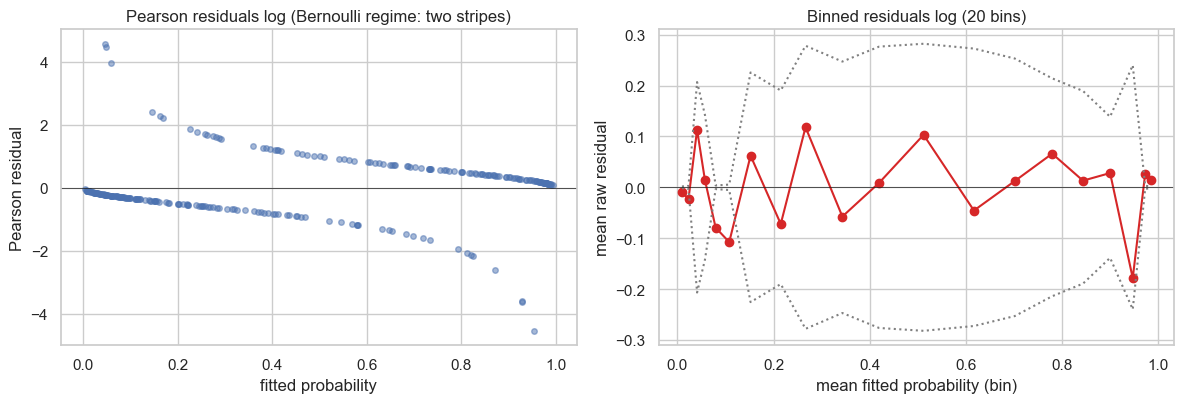

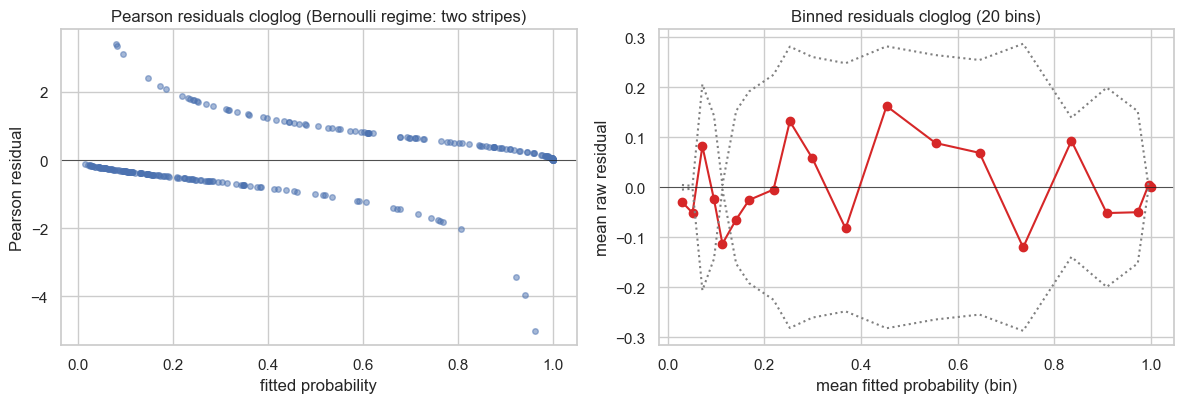

In [18]:
def binned_residuals(model, n_bins=30):
    # Binned residual plot (Gelman & Hill 2006, section 5.3).
    # Sort observations by fitted probability, split into n_bins equal-count bins,
    # plot the mean raw residual against the mean fitted probability per bin.
    # The +/- 2/sqrt(n_bin) band is a rough 95% pointwise reference.
    p_hat = np.asarray(model.fittedvalues)
    raw   = np.asarray(model.resid_response)
    order = np.argsort(p_hat)
    p_hat, raw = p_hat[order], raw[order]
    edges = np.linspace(0, len(p_hat), n_bins + 1).astype(int)
    centres, means, bounds = [], [], []
    for a, b in zip(edges[:-1], edges[1:]):
        if b - a < 2:
            continue
        centres.append(p_hat[a:b].mean())
        means.append(raw[a:b].mean())
        bounds.append(2 * raw[a:b].std(ddof=1) / np.sqrt(b - a))
    return np.array(centres), np.array(means), np.array(bounds)


centres, means, bounds = binned_residuals(m_logit, n_bins=20)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
# Pearson residuals vs. fitted — Bernoulli stripes visible.
ax[0].scatter(m_logit.fittedvalues, m_logit.resid_pearson, s=16, alpha=0.5)
ax[0].axhline(0, color="k", lw=0.5)
ax[0].set_xlabel("fitted probability"); ax[0].set_ylabel("Pearson residual")
ax[0].set_title("Pearson residuals log (Bernoulli regime: two stripes)")
# Binned residuals.
ax[1].plot(centres, means, "o-", color="tab:red")
ax[1].plot(centres, bounds, ":", color="gray"); ax[1].plot(centres, -bounds, ":", color="gray")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_xlabel("mean fitted probability (bin)"); ax[1].set_ylabel("mean raw residual")
ax[1].set_title("Binned residuals log (20 bins)")
plt.tight_layout(); plt.show()

centres, means, bounds = binned_residuals(m_cloglog, n_bins=20)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
# Pearson residuals vs. fitted — Bernoulli stripes visible.
ax[0].scatter(m_cloglog.fittedvalues, m_cloglog.resid_pearson, s=16, alpha=0.5)
ax[0].axhline(0, color="k", lw=0.5)
ax[0].set_xlabel("fitted probability"); ax[0].set_ylabel("Pearson residual")
ax[0].set_title("Pearson residuals cloglog (Bernoulli regime: two stripes)")
# Binned residuals.
ax[1].plot(centres, means, "o-", color="tab:red")
ax[1].plot(centres, bounds, ":", color="gray"); ax[1].plot(centres, -bounds, ":", color="gray")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_xlabel("mean fitted probability (bin)"); ax[1].set_ylabel("mean raw residual")
ax[1].set_title("Binned residuals cloglog (20 bins)")
plt.tight_layout(); plt.show()

# Komentář
- První graf znázorňuje rezidua pro předpovědi našeho modelu nemocný/zdravý, nás zajímá hlavně horní křivka, protože ukazuje, zda model nemocného člověka zařadil do zdravých.
- A v tomto případě cloglog je lepší než log, alespoň okometricky.
- Avšak je to pouze vlastnost cloglog, není symetrický.
- Pro heart disease dataset, kde není apriorní důvod očekávat asymetrii mezi "zdravý" a "nemocný", je to mírná vada.
- Dolní křivka (je zdravý, ale model říká, že je nemocný) se vůbec nezměnila.
- Druhý graf ukazuje celkový trend chyb, kterých dopouští model.
- Subjektivně cloglog se zde pohoršilo, objevuje se zde více větších kladných hodnot (chyba 2. druhu je větší, model podcenil nemocného člověka).
- Tvar chyb v obou případech je akceptovatelný, nelze jednoznačně usoudit z grafu, který přístup je lepší.
- Mojí osobní preferencí je log, binned residuals se mi zde líbí mnohém víc.


In [19]:
def hosmer_lemeshow(model, g=10):
    # Hosmer-Lemeshow C-hat goodness-of-fit test.
    # Returns: chi^2 statistic, degrees of freedom, p-value, and the 2xG table
    # of observed vs. expected successes per decile of fitted risk.
    p_hat = np.asarray(model.fittedvalues)
    y     = np.asarray(model.model.endog)
    # Equal-count bins; use pd.qcut to handle ties in fitted probabilities.
    bins = pd.qcut(p_hat, q=g, labels=False, duplicates="drop")
    G    = bins.max() + 1
    obs_1, exp_1, n_g = [], [], []
    for k in range(G):
        mask = bins == k
        n_g.append(mask.sum())
        obs_1.append(y[mask].sum())
        exp_1.append(p_hat[mask].sum())
    obs_1, exp_1, n_g = map(np.asarray, (obs_1, exp_1, n_g))
    stat = np.sum((obs_1 - exp_1) ** 2 / (exp_1 * (1 - exp_1 / n_g)))
    df   = G - 2
    p    = 1 - chi2.cdf(stat, df)
    table = pd.DataFrame({
        "n":      n_g,
        "obs_1":  obs_1,
        "exp_1":  exp_1.round(2),
        "obs_0":  n_g - obs_1,
        "exp_0":  (n_g - exp_1).round(2),
    })
    return stat, df, p, table


stat_log, df_log, p_log, tbl_log = hosmer_lemeshow(m_logit, g=10)
print(f"Hosmer-Lemeshow C-hat for log = {stat_log:.3f}  on  df = {df_log}   p = {p_log:.3f}")
print(tbl_log)

stat_cloglog, df_cloglog, p_cloglog, tbl_cloglog = hosmer_lemeshow(m_cloglog, g=10)
print(f"Hosmer-Lemeshow C-hat for cloglog = {stat_cloglog:.3f}  on  df = {df_cloglog}   p = {p_cloglog:.3f}")
print(tbl_cloglog)

Hosmer-Lemeshow C-hat for log = 9.103  on  df = 8   p = 0.334
    n   obs_1   exp_1   obs_0   exp_0
0  28  0.0000  0.4700 28.0000 27.5300
1  27  3.0000  1.3700 24.0000 25.6300
2  27  0.0000  2.5700 27.0000 24.4300
3  27  5.0000  5.0100 22.0000 21.9900
4  28  9.0000  8.6600 19.0000 19.3400
5  27 15.0000 12.7200 12.0000 14.2800
6  27 17.0000 17.8900 10.0000  9.1100
7  27 23.0000 21.9600  4.0000  5.0400
8  27 23.0000 24.9300  4.0000  2.0700
9  28 28.0000 27.4200  0.0000  0.5800
Hosmer-Lemeshow C-hat for cloglog = 6.565  on  df = 8   p = 0.584
    n   obs_1   exp_1   obs_0   exp_0
0  28  0.0000  1.1500 28.0000 26.8500
1  27  3.0000  2.3200 24.0000 24.6800
2  27  1.0000  3.4700 26.0000 23.5300
3  27  5.0000  5.2700 22.0000 21.7300
4  28 10.0000  7.8200 18.0000 20.1800
5  27 13.0000 11.2000 14.0000 15.8000
6  27 18.0000 16.2900  9.0000 10.7100
7  27 21.0000 21.2600  6.0000  5.7400
8  27 24.0000 25.3700  3.0000  1.6300
9  28 28.0000 27.9300  0.0000  0.0700


# Komentář

- Zento test ani u jednoho modelu nezamítá hypotézu o správné kalibraci (logit: C=9.10, p=0.334; cloglog: C=6.57, p=0.584).
- Cloglog má však nižší hodnotu statistiky a vyšší p-hodnotu, což naznačuje mírně lepší kalibraci.
- Rozdíl není dramatický, oba modely jsou v praxi použitelné.
- Pro zajímavost nakoukneme na Deviace, AIC a BIC

In [20]:
print("--------Log--------")
print(m_logit.summary().tables[0])
print(f"AIC: {m_logit.aic:.2f}, BIC: {m_logit.bic:.2f}")

print()

print("--------Cloglog--------")
print(m_cloglog.summary().tables[0])
print(f" AIC: {m_cloglog.aic:.2f}, BIC: {m_cloglog.bic:.2f}")



--------Log--------
                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      259
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -104.62
Date:                Wed, 22 Apr 2026   Deviance:                       209.24
Time:                        13:29:31   Pearson chi2:                     252.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4567
Covariance Type:            nonrobust                                         
AIC: 237.24, BIC: -1243.61

--------Cloglog--------
                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:  

# ----------------------------------------------------------------
## MC1 - MC3
### By Vojtěch Paleta

## MC1: Asymptotic Normality of MLE

In [21]:
K = 1000 # number of replications
beta_true = np.array([-0.5, 1.0, -0.7]) # true values of betas

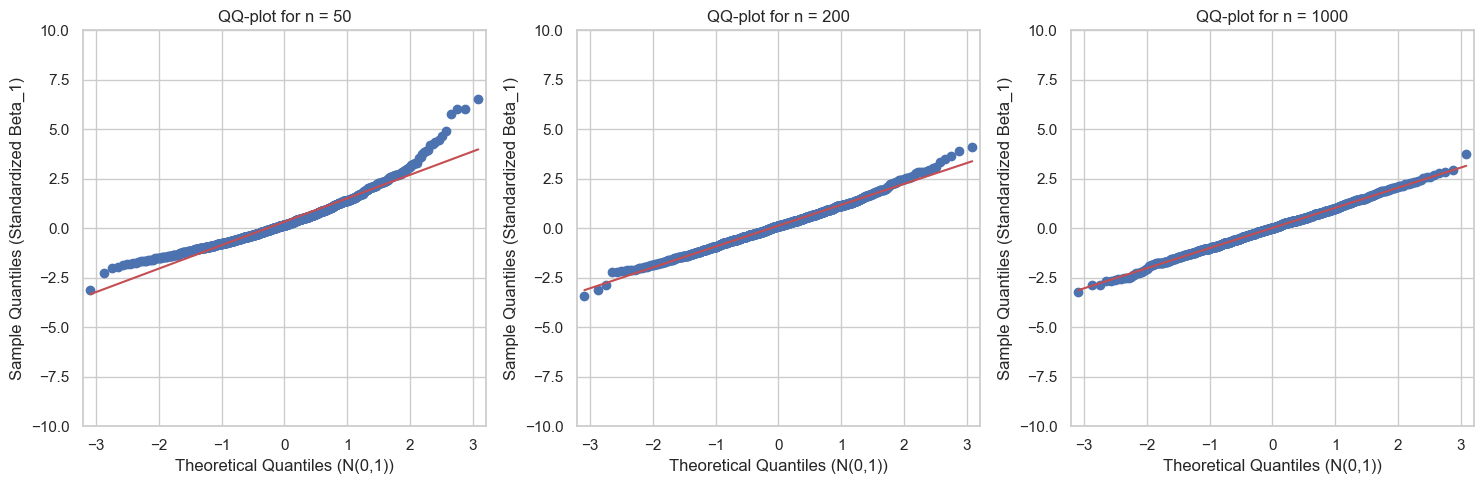

In [22]:
n_values = [50, 200, 1000]

fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 5), squeeze=False)
axes = axes.flatten()

for i, n in enumerate(n_values):

    beta1_standardized_estimators = []

    for _ in range(K):

        X = np.column_stack([np.ones(n), np.random.randn(n), np.random.randn(n)])

        eta_true = X @ beta_true
        pi_true = 1 / (1 + np.exp(-eta_true))

        y = np.random.binomial(1, pi_true)

        glm_fit = sm.GLM(y, X, family=sm.families.Binomial()).fit(disp=False)

        beta_hat_1 = glm_fit.params[1]

        W_diag_true = pi_true * (1 - pi_true)

        W_true = np.diag(W_diag_true)

        I_true = X.T @ W_true @ X
        cov_true = np.linalg.inv(I_true)

        se_theoretical_beta1 = np.sqrt(cov_true[1, 1])

        standardized_estimate = (beta_hat_1 - beta_true[1]) / se_theoretical_beta1
        beta1_standardized_estimators.append(standardized_estimate)

    sm.qqplot(np.array(beta1_standardized_estimators), line='s', ax=axes[i])
    axes[i].set_title(f'QQ-plot for n = {n}')
    axes[i].set_xlabel('Theoretical Quantiles (N(0,1))')
    axes[i].set_ylabel('Sample Quantiles (Standardized Beta_1)')
    axes[i].set_ylim(-10, 10)

plt.tight_layout()
plt.show()

Se zvětšujícím se n si kvantily více odpovídají (což jsme vzhledem k formulaci zmíněné věty očekávali).

## MC2 — Wald CI coverage

In [23]:
n_values = [30, 100, 500]

alpha = 0.05
z_val = norm.ppf(1 - alpha / 2)

empirical_coverage = {}

for n in n_values:

    covered_count = 0

    for _ in range(K):

        X = np.column_stack([np.ones(n), np.random.randn(n), np.random.randn(n)])

        eta_true = X @ beta_true
        pi_true = 1 / (1 + np.exp(-eta_true))

        y = np.random.binomial(1, pi_true)

        glm_fit = sm.GLM(y, X, family=sm.families.Binomial()).fit(disp=False)

        beta_hat_1 = glm_fit.params[1]
        se_beta_1 = glm_fit.bse[1]

        ci_lower = beta_hat_1 - z_val * se_beta_1
        ci_upper = beta_hat_1 + z_val * se_beta_1

        if ci_lower <= beta_true[1] <= ci_upper:
            covered_count += 1

    empirical_coverage[n] = covered_count / K

print(f'Empirical Coverage of {100*(1-alpha)}% Wald CI for Beta_1:')
for n, coverage in empirical_coverage.items():
    print(f"  n = {n}: {coverage:.3f}")

Empirical Coverage of 95.0% Wald CI for Beta_1:
  n = 30: 0.958
  n = 100: 0.950
  n = 500: 0.952


Coverage approach the nominal 0.95 from above. Among the n_values chosen, the largest deviation is for n=30.

## MC3 — Size and power of the three tests

In [24]:
n_values = [50, 500]

beta_2 = np.array([0.0, 0.2, 0.4, 0.6])

alpha = 0.05

rejection_results = {}

for n in n_values:

    for i in range(len(beta_2)):

        beta_true = np.array([-0.5, 1.0, beta_2[i]])
        rejection_counts = {"Wald": 0, "LRT": 0, "Rao": 0}

        for _ in range(K):

            X = np.column_stack([np.ones(n), np.random.randn(n), np.random.randn(n)])

            eta_true = X @ beta_true
            pi_true = 1 / (1 + np.exp(-eta_true))

            y = np.random.binomial(1, pi_true)

            model_full = sm.GLM(y, X, family=sm.families.Binomial()).fit(disp=False)
            model_null = sm.GLM(y, X[:, [0,1]], family=sm.families.Binomial()).fit(disp=False)

            W_stat = (model_full.params[2])**2 / model_full.cov_params()[2,2]
            p_value = chi2.sf(W_stat, 1)

            if p_value < alpha:
                rejection_counts["Wald"] += 1

            LRT_stat = 2 * (model_full.llf - model_null.llf)
            p_value = chi2.sf(LRT_stat, 1)

            if p_value < alpha:
                rejection_counts["LRT"] += 1

            Rao_result = model_null.score_test(X[:, [2]])
            p_value = Rao_result[1].item()

            if p_value < alpha:
                rejection_counts["Rao"] += 1

        rejection_results[(n, beta_2[i])] = rejection_counts

print(f"Rejection rate at nominal level {alpha}:")
for (n, beta_2_val), results in rejection_results.items():
    print(f"  n = {n}, beta_2 = {beta_2_val}:")
    for test, count in results.items():
        print(f"{test}: {count/K:.3f})")

Rejection rate at nominal level 0.05:
  n = 50, beta_2 = 0.0:
Wald: 0.040)
LRT: 0.055)
Rao: 0.050)
  n = 50, beta_2 = 0.2:
Wald: 0.076)
LRT: 0.099)
Rao: 0.089)
  n = 50, beta_2 = 0.4:
Wald: 0.209)
LRT: 0.245)
Rao: 0.232)
  n = 50, beta_2 = 0.6:
Wald: 0.413)
LRT: 0.459)
Rao: 0.453)
  n = 500, beta_2 = 0.0:
Wald: 0.048)
LRT: 0.050)
Rao: 0.050)
  n = 500, beta_2 = 0.2:
Wald: 0.511)
LRT: 0.514)
Rao: 0.513)
  n = 500, beta_2 = 0.4:
Wald: 0.978)
LRT: 0.978)
Rao: 0.978)
  n = 500, beta_2 = 0.6:
Wald: 1.000)
LRT: 1.000)
Rao: 1.000)


# ----------------------------------------------------------------
## MC4 - MC6
### By Vojtěch Remiš

In [25]:
# Importy pro MC4-6
import numpy as np
import statsmodels.api as sm
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.families.links import Logit, Probit
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.stats import skew

In [26]:
## MC4 — Fisherova informace vs. empirická kovariance
# Ověřujeme, že Cov(β̂) z opakovaných simulací odpovídá teoretické (X^TWX)^-1


rng = np.random.default_rng(42)
K = 2000 # Počet replikací
n = 500  # Počet pozorování
beta_true = np.array([-0.5, 1.0, -0.7])

beta_hats_list = np.zeros((K, len(beta_true)))
cov_theory_list = np.zeros((K, len(beta_true), len(beta_true)))

def perform_replication(size, true_parameter):
    # Generuji prediktory a data
    x1 = rng.normal(size=size)
    x2 = rng.normal(size=size)
    X = np.column_stack([np.ones(n), x1, x2])

    eta = X @ true_parameter
    pi = 1 / (1 + np.exp(-eta))
    y = rng.binomial(1, pi)

    # Fittuji logistickou regresi
    res = sm.GLM(y, X, family=sm.families.Binomial()).fit(disp=False)

    # Teoretická kovariance: (X^TWX)^-1 na skutečném beta (beta_true)
    w = pi * (1 - pi)
    XtWX = X.T @ (w[:, None] * X)
    return res.params, np.linalg.inv(XtWX)


for k in range(K):
    beta_hats, cov_theory = perform_replication(n, beta_true)
    beta_hats_list[k] = beta_hats
    cov_theory_list[k] = cov_theory

# Empirická kovarianční matice z K odhadů
Cov_emp = np.cov(beta_hats_list, rowvar=False, ddof=1)

# Průměrná teoretická kovarianční matice
Cov_theory_avg = cov_theory_list.mean(axis=0)

# Poměr empirická / teoretická  (měl by být ~ 1)
# Poměr prvků matic
Ratio = Cov_emp / Cov_theory_avg

print("=" * 55)
print("Fisherova informace vs. empirická kovariance")
print("=" * 55)
print(f"\nPočet replikací K = {K}, velikost vzorku n = {n}")
print(f"Pravé β = {beta_true}\n")

labels = ["β0 (intercept)", "β1", "β2"]
print("Empirická kovariance Cov(β̂):")
print(pd.DataFrame(Cov_emp, index=labels, columns=labels).round(6))

print("\nPrůměrná teoretická (X^TWX)^-1:")
print(pd.DataFrame(Cov_theory_avg, index=labels, columns=labels).round(6))

print("\nPoměr empirická / teoretická:")
print(pd.DataFrame(Ratio, index=labels, columns=labels).round(4))

print("\nPoměry blízké 1.0 potvrzují, že asymptotický vzorec Cov(β̂) ~ (X^TWX)^-1 platí.")

Fisherova informace vs. empirická kovariance

Počet replikací K = 2000, velikost vzorku n = 500
Pravé β = [-0.5  1.  -0.7]

Empirická kovariance Cov(β̂):
                β0 (intercept)      β1      β2
β0 (intercept)          0.0112 -0.0026  0.0019
β1                     -0.0026  0.0156 -0.0033
β2                      0.0019 -0.0033  0.0134

Průměrná teoretická (X^TWX)^-1:
                β0 (intercept)      β1      β2
β0 (intercept)          0.0112 -0.0022  0.0015
β1                     -0.0022  0.0152 -0.0031
β2                      0.0015 -0.0031  0.0129

Poměr empirická / teoretická:
                β0 (intercept)     β1     β2
β0 (intercept)          1.0056 1.1665 1.2361
β1                      1.1665 1.0256 1.0649
β2                      1.2361 1.0649 1.0350

Poměry blízké 1.0 potvrzují, že asymptotický vzorec Cov(β̂) ~ (X^TWX)^-1 platí.


Misspecifikace linkové funkce (probit vs. logit)
Teoretický faktor π/√3 = 1.8138

----------------------------------- 


Pravé β_probit = [-0.3  0.7]. std(η) = 0.699
Průměrný β̂_probit = [-0.3033, 0.7030]
Průměrný β̂_logit  = [-0.5064, 1.1764]

Poměr β̂_logit / β̂_probit = [1.6696, 1.6733]

Průměrné RMSE predikcí:
	Probit (správný model): 0.02327
	Logit (špatný model):  0.02420


C:\Users\francji1\AppData\Local\Temp\ipykernel_25900\3920137500.py:81: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


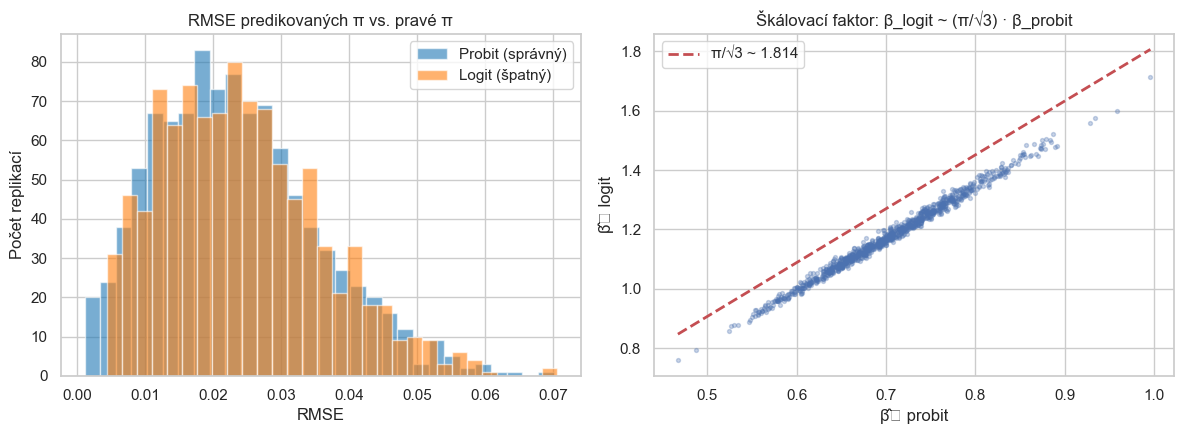

----------------------------------- 


Pravé β_probit = [-5.3  8.6]. std(η) = 8.583
Průměrný β̂_probit = [-5.6645, 9.2039]
Průměrný β̂_logit  = [-10.2153, 16.6030]

Poměr β̂_logit / β̂_probit = [1.8034, 1.8039]

Průměrné RMSE predikcí:
	Probit (správný model): 0.01912
	Logit (špatný model):  0.02032


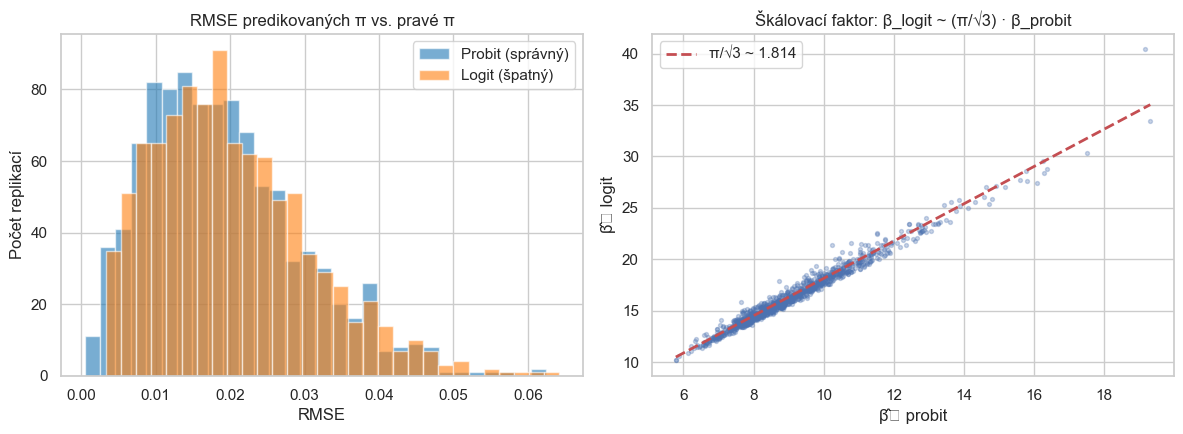


Empiricky se mi zdá: Pokud je eta_true přibližně 0 (což je případ [-0.3, 0.7] ze zadání),
 pak scale faktor je aproximován hodnotou 1.6 (viz T4), pokud ne, pak hodnotou ~ π/√3.


In [27]:
## MC5 — Misspecifikace linkové funkce
# Data generujeme z Probit modelu, ale fittujeme probitem i logitem.
# Ověřujeme, zda pro škálovací faktor platí beta_logit / beta_probit ~ π/√3 ~ 1.814
# a porovnáváme predikované pravděpodobnosti (RMSE).

rng_mc5 = np.random.default_rng(42)
K = 1000
n = 500

def perform_mc5(n, K, beta_probit_true):
    beta_logit_hats  = np.zeros((K, 2))
    beta_probit_hats = np.zeros((K, 2))
    rmse_logit  = np.zeros(K)
    rmse_probit = np.zeros(K)

    eta_stds = np.zeros(K)

    for k in range(K):
        x = rng_mc5.normal(size=n)
        X = np.column_stack([np.ones(n), x])

        # Generuji data z Probit modelu
        eta_true = X @ beta_probit_true

        eta_stds[k] = np.std(eta_true)

        pi_true = norm.cdf(eta_true)

        y = rng_mc5.binomial(1, pi_true)

        # Fitnu probit (správný model)
        res_probit = sm.GLM(y, X, family=sm.families.Binomial(link=Probit())).fit(disp=False)
        beta_probit_hats[k] = res_probit.params

        # Fitnu logit (špatný model)
        res_logit = sm.GLM(y, X, family=sm.families.Binomial(link=Logit())).fit(disp=False)
        beta_logit_hats[k] = res_logit.params

        # RMSE predikovaných pravděpodobností vs. pravé \pi
        rmse_probit[k] = np.sqrt(np.mean((res_probit.fittedvalues - pi_true)**2))
        rmse_logit[k] = np.sqrt(np.mean((res_logit.fittedvalues  - pi_true)**2))

    # Průměrné odhady koeficientů
    mean_probit = beta_probit_hats.mean(axis=0)
    mean_logit  = beta_logit_hats.mean(axis=0)

    # Škálovací faktor
    scale_factor = mean_logit / mean_probit
    theoretical_factor = np.pi / np.sqrt(3) # Teoretický

    eta_stds_mean = np.mean(eta_stds)

    print("-" * 35, "\n")
    print(f"\nPravé β_probit = {beta_probit_true}. std(η) = {eta_stds_mean:.3f}")

    print(f"Průměrný β̂_probit = [{mean_probit[0]:.4f}, {mean_probit[1]:.4f}]")
    print(f"Průměrný β̂_logit  = [{mean_logit[0]:.4f}, {mean_logit[1]:.4f}]")
    print(f"\nPoměr β̂_logit / β̂_probit = [{scale_factor[0]:.4f}, {scale_factor[1]:.4f}]")

    print(f"\nPrůměrné RMSE predikcí:")
    print(f"\tProbit (správný model): {rmse_probit.mean():.5f}")
    print(f"\tLogit (špatný model):  {rmse_logit.mean():.5f}")

    # Graf porovnání RMSE
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.hist(rmse_probit, bins=30, alpha=0.6, label="Probit (správný)", color="tab:blue")
    ax1.hist(rmse_logit,  bins=30, alpha=0.6, label="Logit (špatný)",  color="tab:orange")
    ax1.set_xlabel("RMSE"); ax1.set_ylabel("Počet replikací")
    ax1.set_title("RMSE predikovaných π vs. pravé π")
    ax1.legend()

    # β̂_logit vs. β̂_probit pro slope (β1)
    ax2.scatter(beta_probit_hats[:, 1], beta_logit_hats[:, 1], s=8, alpha=0.3)
    grid = np.array([beta_probit_hats[:, 1].min(), beta_probit_hats[:, 1].max()])
    ax2.plot(grid, theoretical_factor * grid, "r--", lw=2, label=f"π/√3 ~ {theoretical_factor:.3f}")
    ax2.set_xlabel("β̂₁ probit"); ax2.set_ylabel("β̂₁ logit")
    ax2.set_title("Škálovací faktor: β_logit ~ (π/√3) · β_probit")
    ax2.legend()

    plt.tight_layout(); plt.show()



print("=" * 55)
print(f"Misspecifikace linkové funkce (probit vs. logit)")
print("=" * 55)
theoretical_factor = np.pi / np.sqrt(3) # Teoretický
print(f"Teoretický faktor π/√3 = {theoretical_factor:.4f}\n")

perform_mc5(n, K, np.array([-0.3, 0.7])) # eta_true ~ 0
perform_mc5(n, K, np.array([-5.3, 8.6]))

print(f"\nEmpiricky se mi zdá: Pokud je eta_true přibližně 0 (což je případ [-0.3, 0.7] ze zadání),\n",
      "pak scale faktor je aproximován hodnotou 1.6 (viz T4), pokud ne, pak hodnotou ~ π/√3.")

In [28]:
def irls_binary(X, y, n=None, tol=1e-8, max_iter=100):
    # IRLS for the binomial GLM with canonical (logit) link.
    # X : (N, p) design matrix (include the intercept column explicitly).
    # y : (N,) successes; n : (N,) trials (all ones = Bernoulli).
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if n is None:
        n = np.ones_like(y)
    n = np.asarray(n, dtype=float)

    # Start at the mean response.
    pi = np.clip((y + 0.5) / (n + 1), 1e-3, 1 - 1e-3)
    eta = np.log(pi / (1 - pi))
    beta = np.linalg.lstsq(X, eta, rcond=None)[0]

    history = []
    for t in range(max_iter):
        eta = X @ beta
        pi = 1 / (1 + np.exp(-eta))
        mu = n * pi
        W = n * pi * (1 - pi)                               # IRLS weights
        z  = eta + (y - mu) / W                             # working response
        XtWX = (X * W[:, None]).T @ X
        XtWz = (X * W[:, None]).T @ z
        beta_new = np.linalg.solve(XtWX, XtWz)
        diff = np.max(np.abs(beta_new - beta))
        history.append(diff)
        beta = beta_new
        if diff < tol:
            break
    cov = np.linalg.inv((X * (n * pi * (1 - pi))[:, None]).T @ X)
    return beta, cov, history


IRLS konvergence a podmíněnost X^TX
     ρ  IRLS průměr  IRLS medián  IRLS max cond(X^TX) medián
0.0000       5.4000            5         6               1.2
0.5000       5.0000            5         6               3.0
0.9000       4.8000            5         5              19.0
0.9900       4.4000            4         5             200.1
0.9990       4.4000            4         5            2020.3


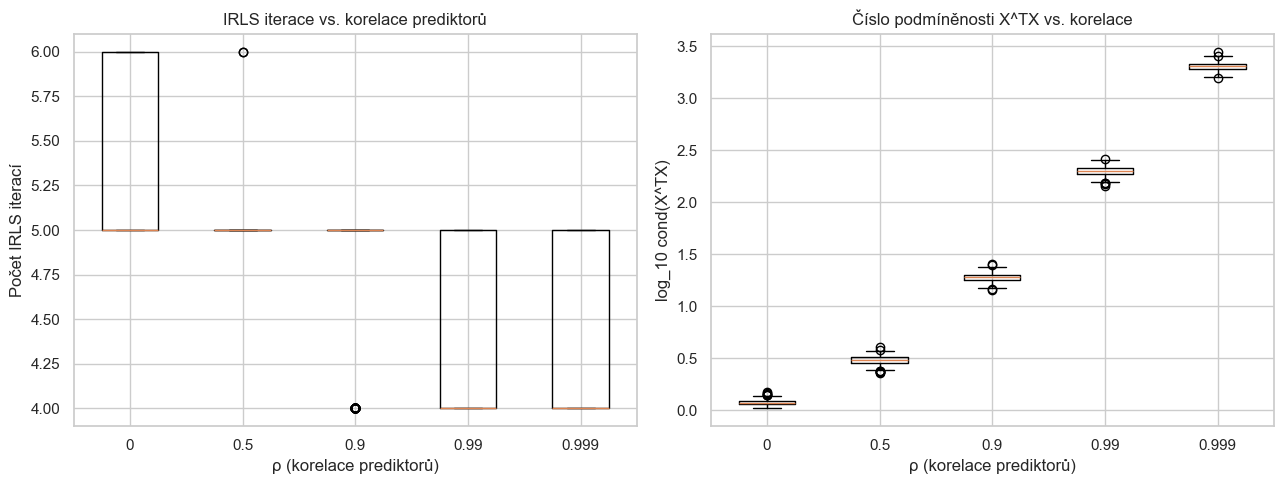


S rostoucí korelací ρ roste cond(X^TX) exponenciálně, ale IRLS konverguje stále
 rychle (~ 5-7 iterací) i pro ρ = 0.999. Konvergence by se se zvětšující ρ dokonce
 mírně zrychluje (nejspíš kvůli tomu, že x_1 a x_2 jsou při vysokém ρ velice blízko sebe,
což redukuje úlohu na nižší dimenzi).


In [29]:
## MC6 — Konvergence IRLS a podmíněnost při korelovaných prediktorech
# Generujeme korelované prediktory X1, X2 s Pearsonovou korelací ρ.
# Pro každé ρ fittujeme logistický GLM a zaznamenáváme:
# a) počet IRLS iterací do konvergence
# b) číslo podmíněnosti matice X^T X

rng_mc6 = np.random.default_rng(42)
K_mc6 = 500
n_mc6 = 500
beta_true_mc6 = np.array([-0.5, 1.0, -0.7])
rhos = [0, 0.5, 0.9, 0.99, 0.999]

results_mc6 = []

for rho in rhos:
    iters_list = []
    cond_list = []

    for k in range(K_mc6):
        # Generujeme korelované prediktory (chceme aby byly z N(0, 1) s daným korelačním koeficientem ρ)
        z1 = rng_mc6.normal(size=n_mc6)
        z2 = rng_mc6.normal(size=n_mc6)
        x1 = z1
        x2 = rho * z1 + np.sqrt(1 - rho**2) * z2  # corr(x1, x2) = rho

        X = np.column_stack([np.ones(n_mc6), x1, x2])

        # Podmíněnost X^T X
        XtX = X.T @ X
        cond = np.linalg.cond(XtX)
        cond_list.append(cond)

        # Generujeme data
        eta = X @ beta_true_mc6
        pi = 1 / (1 + np.exp(-eta))
        y = rng_mc6.binomial(1, pi)

        # Fittneme pomocí vlastní IRLS funkce
        _, _, history = irls_binary(X, y)
        iters_list.append(len(history))

    results_mc6.append({
        "rho": rho,
        "mean_iters": np.mean(iters_list),
        "median_iters": np.median(iters_list),
        "max_iters": np.max(iters_list),
        "mean_cond": np.mean(cond_list),
        "median_cond": np.median(cond_list),
        "iters_list": iters_list,
        "cond_list": cond_list,
    })

print("\n" + "=" * 55)
print("IRLS konvergence a podmíněnost X^TX")
print("=" * 55)
df_mc6 = pd.DataFrame([{
    "ρ": r["rho"],
    "IRLS průměr": round(r["mean_iters"], 1),
    "IRLS medián": int(r["median_iters"]),
    "IRLS max": r["max_iters"],
    "cond(X^TX) medián": f'{r["median_cond"]:.1f}',
} for r in results_mc6])
print(df_mc6.to_string(index=False))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot počtu iterací pro každé ρ
bp_data = [r["iters_list"] for r in results_mc6]
bp_labels = [str(r["rho"]) for r in results_mc6]
ax1.boxplot(bp_data, tick_labels=bp_labels)
ax1.set_xlabel("ρ (korelace prediktorů)")
ax1.set_ylabel("Počet IRLS iterací")
ax1.set_title("IRLS iterace vs. korelace prediktorů")
ax1.grid(True, axis="y")

# Boxplot log10(cond) pro každé ρ
bp_cond = [np.log10(r["cond_list"]) for r in results_mc6]
ax2.boxplot(bp_cond, tick_labels=bp_labels)
ax2.set_xlabel("ρ (korelace prediktorů)")
ax2.set_ylabel("log_10 cond(X^TX)")
ax2.set_title("Číslo podmíněnosti X^TX vs. korelace")
ax2.grid(True, axis="y")

plt.tight_layout(); plt.show()

print("\nS rostoucí korelací ρ roste cond(X^TX) exponenciálně, ale IRLS konverguje stále\n",
      "rychle (~ 5-7 iterací) i pro ρ = 0.999. Konvergence by se se zvětšující ρ dokonce\n",
      "mírně zrychluje (nejspíš kvůli tomu, že x_1 a x_2 jsou při vysokém ρ velice blízko sebe,\n"
      "což redukuje úlohu na nižší dimenzi).")